# BigMart Sales Prediction — Multiple Linear Regression

**Problem statement:** BigMart wants to understand which product and outlet properties influence sales the most, so they can predict `Item_Outlet_Sales` for any given product-store combination using Multiple Linear Regression.

**Workflow:** A) Data Inspection &rarr; B) Cleaning &rarr; C) EDA &rarr; D) Feature Engineering &rarr; E) Model Training &rarr; F) Evaluation &rarr; G) Summary.

### Part A — Data Inspection
Goal: understand the dataset's shape, types, value ranges, and data-quality issues *before* touching anything — so every cleaning decision in Part B is justified by something observed here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sales_df = pd.read_csv("Sales_Data.csv")
sales_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [4]:
sales_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [5]:
sales_df.describe(include="object")

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8523,8523,8523,8523,6113,8523,8523
unique,1559,5,16,10,3,3,4
top,FDW13,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,10,5089,1232,935,2793,3350,5577


In [6]:
sales_df.nunique()

Item_Identifier              1559
Item_Weight                   415
Item_Fat_Content                5
Item_Visibility              7880
Item_Type                      16
Item_MRP                     5938
Outlet_Identifier              10
Outlet_Establishment_Year       9
Outlet_Size                     3
Outlet_Location_Type            3
Outlet_Type                     4
Item_Outlet_Sales            3493
dtype: int64

In [7]:
missing = pd.DataFrame({
    "missing_count": sales_df.isnull().sum(),
    "missing_pct": (sales_df.isnull().sum() / len(sales_df) * 100).round(2)
})
missing[missing["missing_count"] > 0]

,missing_count,missing_pct
Item_Weight,1463,17.17
Outlet_Size,2410,28.28


In [8]:
sales_df.duplicated().sum()

0

**Initial observations**
- 8,523 rows × 12 columns; no duplicate rows.
- Two columns have missing values: `Item_Weight` (~17%) and `Outlet_Size` (~28%) → handled in Part B.
- `Item_Visibility` has a minimum of 0, which is implausible for a stocked product — likely disguised missing values to fix later.
- `Item_Fat_Content` has inconsistent labels (Low Fat / LF / low fat, Regular / reg) → needs standardising.
- `Item_Identifier` is near-unique (1,559 values) and `Outlet_Identifier` has only 10 — both are ID columns, candidates to drop before modelling.
- Target (`Item_Outlet_Sales`) ranges widely (~33 to ~13,087) with mean > median, hinting at right-skew.

### Part B — Handling Missing Values & Cleaning
Two columns have missing values (`Item_Weight`, `Outlet_Size`). I also treat `Item_Visibility = 0` as disguised-missing and standardise inconsistent `Item_Fat_Content` labels. Each choice is justified below.

**Item_Weight:** each product has a fixed true weight, so I fill from the item's own average. The skew (≈ 0.08) confirms the global mean is a safe fallback for any item missing everywhere.

In [9]:
sales_df["Item_Weight"].skew()

0.0824262091221237

In [10]:
# Primary: fill from each product's own known weight
item_weight_map = sales_df.groupby("Item_Identifier")["Item_Weight"].transform("mean")
sales_df["Item_Weight"] = sales_df["Item_Weight"].fillna(item_weight_map)
# Fallback: global mean for any item missing everywhere
sales_df["Item_Weight"] = sales_df["Item_Weight"].fillna(sales_df["Item_Weight"].mean())
sales_df["Item_Weight"].isnull().sum()

0

**Outlet_Size:** missingness is concentrated in specific outlet types, so I impute the most common size *within each Outlet_Type* rather than a single global mode.

In [11]:
pd.crosstab(sales_df["Outlet_Type"], sales_df["Outlet_Size"])

Outlet_Size,High,Medium,Small
Outlet_Type,,,
Grocery Store,0,0,528
Supermarket Type1,932,930,1860
Supermarket Type2,0,928,0
Supermarket Type3,0,935,0


In [12]:
sales_df[sales_df["Outlet_Size"].isnull()]["Outlet_Type"].value_counts()

Outlet_Type
Supermarket Type1    1855
Grocery Store         555
Name: count, dtype: int64

In [13]:
mode_per_type = sales_df.groupby("Outlet_Type")["Outlet_Size"].apply(lambda x: x.mode()[0])
mode_per_type

Outlet_Type
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: Outlet_Size, dtype: object

In [14]:
sales_df["Outlet_Size"] = sales_df["Outlet_Size"].fillna(
    sales_df["Outlet_Type"].map(mode_per_type)
)
sales_df["Outlet_Size"].isnull().sum()

0

**Item_Fat_Content:** the same category is written several ways (LF, low fat, reg). I collapse them to two clean labels so the model doesn't treat them as separate categories.

In [15]:
sales_df["Item_Fat_Content"].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [16]:
sales_df["Item_Fat_Content"] = sales_df["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})
sales_df["Item_Fat_Content"].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

**Item_Visibility:** a value of 0 is impossible for a stocked product, so I treat 0 as missing and replace it with that product's average visibility.

In [17]:
(sales_df["Item_Visibility"] == 0).sum()

526

In [18]:
visibility_avg = sales_df.groupby("Item_Identifier")["Item_Visibility"].mean()
mask = sales_df["Item_Visibility"] == 0
sales_df.loc[mask, "Item_Visibility"] = sales_df.loc[mask, "Item_Identifier"].map(visibility_avg)
(sales_df["Item_Visibility"] == 0).sum()

0

**Note on data leakage:** the imputations above (weight average, visibility average) are computed on the full dataset before the train/test split. Strictly, these statistics should be learned from the training set only and applied to the test set — otherwise test information leaks into training. For this project I impute on the full data for simplicity; the production-correct approach is a scikit-learn `Pipeline` / `ColumnTransformer` fit inside the split.

### Part C — Exploratory Data Analysis
Explore how the target relates to numeric and categorical features, to see which variables are likely to matter before modelling.

**Q9.** Plot the distribution of `Item_Outlet_Sales` and calculate its skewness.

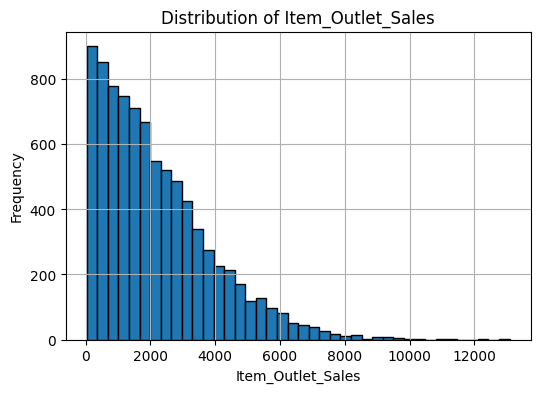

In [19]:
sales_df["Item_Outlet_Sales"].hist(figsize=(6,4), bins=40, edgecolor="black")
plt.title("Distribution of Item_Outlet_Sales")
plt.xlabel("Item_Outlet_Sales")
plt.ylabel("Frequency")
plt.show()

In [20]:
sales_df["Item_Outlet_Sales"].skew()

1.1775306028542796

**Answer:** The distribution is strongly right-skewed (skewness ≈ 1.18) — a long tail of high-sales items pulls the mean above the median. This motivates testing a log-transform later (Q21).

**Q10.** Scatter plot of each numeric feature against the target. Which shows the clearest trend?

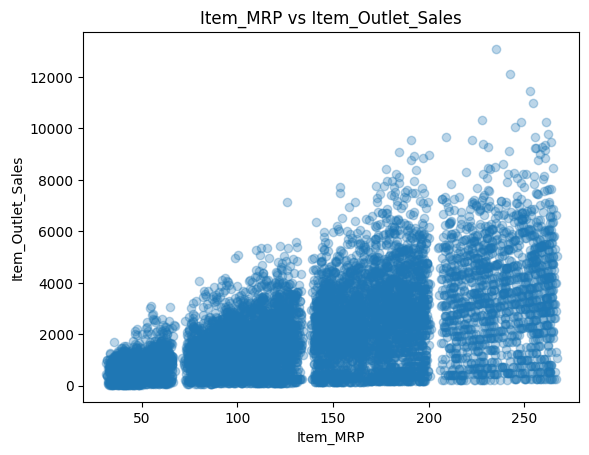

In [21]:
plt.scatter(sales_df["Item_MRP"], sales_df["Item_Outlet_Sales"], alpha=0.3)
plt.title("Item_MRP vs Item_Outlet_Sales")
plt.xlabel("Item_MRP")
plt.ylabel("Item_Outlet_Sales")
plt.show()

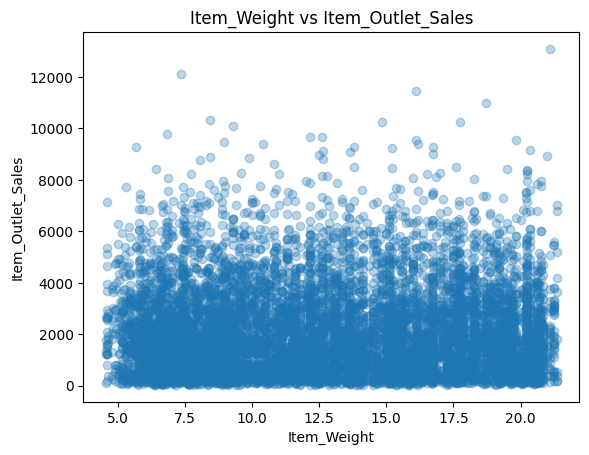

In [22]:
plt.scatter(sales_df["Item_Weight"], sales_df["Item_Outlet_Sales"], alpha=0.3)
plt.title("Item_Weight vs Item_Outlet_Sales")
plt.xlabel("Item_Weight")
plt.ylabel("Item_Outlet_Sales")
plt.show()

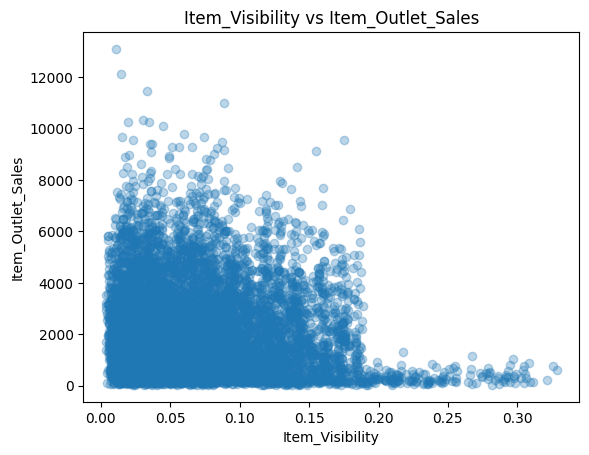

In [23]:
plt.scatter(sales_df["Item_Visibility"], sales_df["Item_Outlet_Sales"], alpha=0.3)
plt.title("Item_Visibility vs Item_Outlet_Sales")
plt.xlabel("Item_Visibility")
plt.ylabel("Item_Outlet_Sales")
plt.show()

**Answer:** `Item_MRP` shows the clearest trend — sales rise with price and form distinct vertical price bands. `Item_Weight` and `Item_Visibility` show no visible relationship (flat clouds).

**Q11.** Boxplot of each categorical feature against the target. Which shows the most dramatic difference?

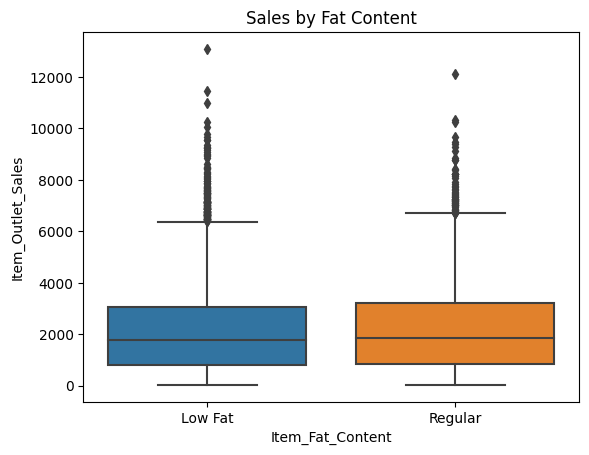

In [24]:
sns.boxplot(x="Item_Fat_Content", y="Item_Outlet_Sales", data=sales_df)
plt.title("Sales by Fat Content")
plt.show()

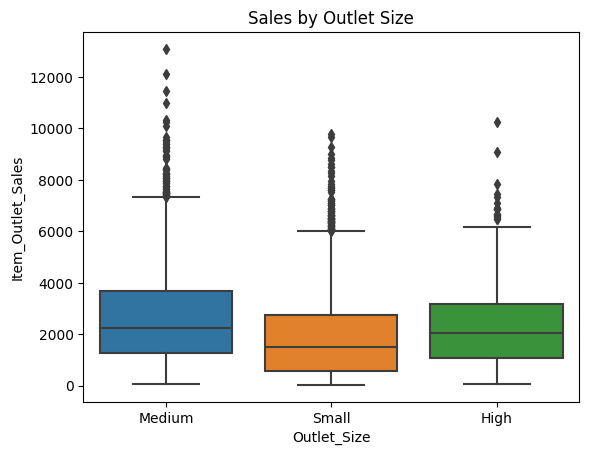

In [25]:
sns.boxplot(x="Outlet_Size", y="Item_Outlet_Sales", data=sales_df)
plt.title("Sales by Outlet Size")
plt.show()

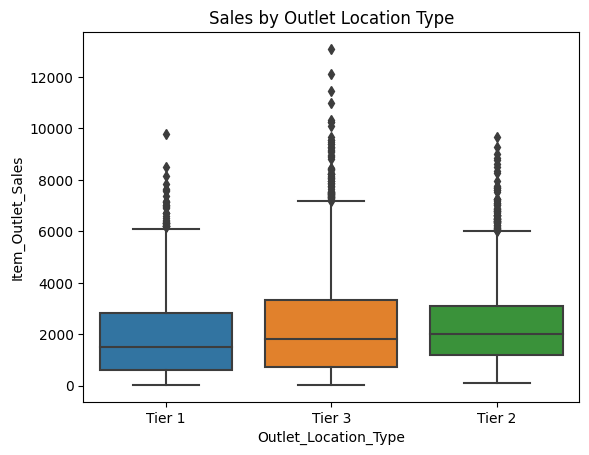

In [26]:
sns.boxplot(x="Outlet_Location_Type", y="Item_Outlet_Sales", data=sales_df)
plt.title("Sales by Outlet Location Type")
plt.show()

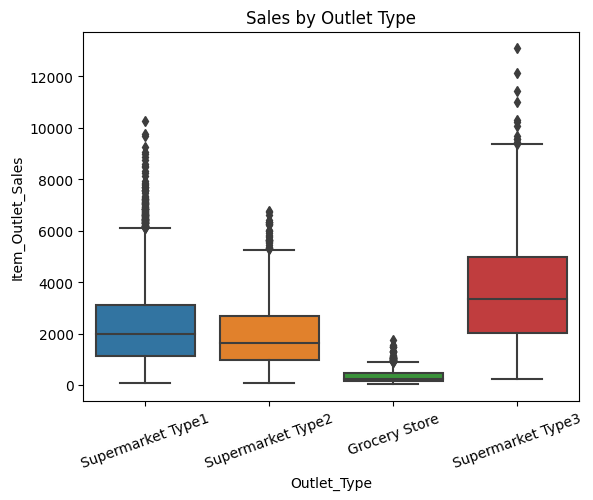

In [27]:
sns.boxplot(x="Outlet_Type", y="Item_Outlet_Sales", data=sales_df)
plt.title("Sales by Outlet Type")
plt.xticks(rotation=20)
plt.show()

**Answer:** `Outlet_Type` shows the most dramatic difference — Supermarket Type3 has far higher median sales than Grocery Store. `Item_Fat_Content` barely differs between categories.

**Q12.** Correlation heatmap of the numeric columns. Which correlates most with the target?

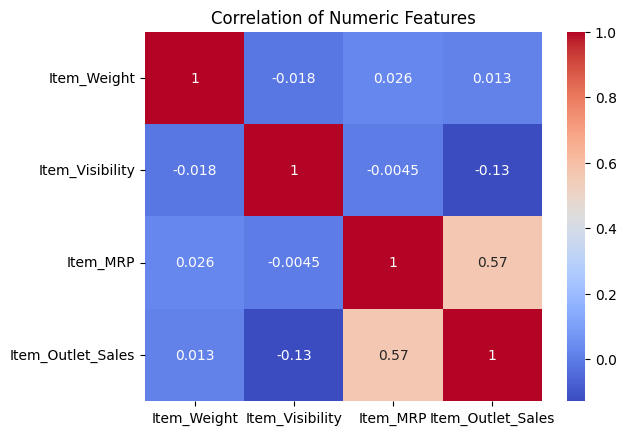

In [28]:
sns.heatmap(
    sales_df[["Item_Weight", "Item_Visibility", "Item_MRP", "Item_Outlet_Sales"]].corr(),
    annot=True, cmap="coolwarm"
)
plt.title("Correlation of Numeric Features")
plt.show()

**Answer:** `Item_MRP` has the strongest correlation with `Item_Outlet_Sales` (≈ 0.57). `Item_Weight` is near zero and `Item_Visibility` is weakly negative.

### Part D — Feature Engineering
Create `Outlet_Age`, drop the ID columns and the now-redundant establishment year, then one-hot encode the remaining categorical features.

**Q14 — Why drop Item_Identifier and Outlet_Identifier?**

Both are ID labels, not measurements. `Item_Identifier` is near-unique (1,559 values); one-hot encoding it would create hundreds of columns and let the model memorise individual products instead of learning patterns — useless on unseen items. `Outlet_Identifier` (10 values) is less extreme, but its real information is already captured by `Outlet_Type`, `Outlet_Size`, `Outlet_Location_Type` and `Outlet_Age`. High-cardinality ID columns help a model memorise, not generalise, so I dropped both.

In [29]:
# 2013 = the year this dataset was collected (BigMart competition reference year)
sales_df["Outlet_Age"] = 2013 - sales_df["Outlet_Establishment_Year"]
sales_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,4
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,14
3,FDX07,19.20,Regular,0.015274,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,15
4,NCD19,8.93,Low Fat,0.008082,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,26


In [30]:
# Drop ID columns and the establishment year (now represented by Outlet_Age)
sales_df = sales_df.drop(
    columns=["Item_Identifier", "Outlet_Identifier", "Outlet_Establishment_Year"],
    errors="ignore"
)
sales_df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,9.30,Low Fat,0.016047,Dairy,249.8092,Medium,Tier 1,Supermarket Type1,3735.1380,14
1,5.92,Regular,0.019278,Soft Drinks,48.2692,Medium,Tier 3,Supermarket Type2,443.4228,4
2,17.50,Low Fat,0.016760,Meat,141.6180,Medium,Tier 1,Supermarket Type1,2097.2700,14
3,19.20,Regular,0.015274,Fruits and Vegetables,182.0950,Small,Tier 3,Grocery Store,732.3800,15
4,8.93,Low Fat,0.008082,Household,53.8614,High,Tier 3,Supermarket Type1,994.7052,26


**Q15.** One-hot encode the remaining categorical columns with `drop_first=True`.

In [31]:
df_encoded = pd.get_dummies(
    sales_df,
    columns=["Item_Fat_Content", "Item_Type", "Outlet_Size", "Outlet_Location_Type", "Outlet_Type"],
    drop_first=True
)
df_encoded.shape

(8523, 28)

**Answer:** After one-hot encoding with `drop_first=True` the dataframe has **28 columns** — 27 model features plus the target `Item_Outlet_Sales`.

### Part E — Model Training
**Q16.** Split into features `x` and target `y`, then into train/test (80/20, `random_state=42`) and fit a Linear Regression.

In [32]:
x = df_encoded.drop(columns=["Item_Outlet_Sales"])
y = df_encoded["Item_Outlet_Sales"]
x.shape, y.shape

((8523, 27), (8523,))

In [33]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
coef_df = pd.DataFrame({"Feature": x.columns, "Coefficient": lr.coef_})
coef_df.sort_values("Coefficient", key=abs, ascending=False)

,Feature,Coefficient
26,Outlet_Type_Supermarket Type3,3582.989130
24,Outlet_Type_Supermarket Type1,1599.272529
25,Outlet_Type_Supermarket Type2,1321.178589
21,Outlet_Size_Small,-644.814589
20,Outlet_Size_Medium,-567.176762
23,Outlet_Location_Type_Tier 3,-326.499722
1,Item_Visibility,-302.599095
16,Item_Type_Seafood,228.364549
8,Item_Type_Dairy,-91.134736
22,Outlet_Location_Type_Tier 2,-85.094167


In [36]:
y_pred = lr.predict(x_test)

### Part F — Evaluation

In [37]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2  :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2  : 0.5788226151587408
MAE : 792.4872032920939
MSE : 1144747.5247344542
RMSE: 1069.9287475035214


**Interpretation:** the model explains ~58% of the variance in sales (R² ≈ 0.58) with a typical error of ~₹793 (MAE). A solid linear baseline — the moderate R² is expected, since sales also depend on factors not in this data.

#### Q19 (Bonus) — Scaled coefficients for fair comparison
Raw coefficients aren't comparable across features on different scales. I standardise **only the continuous features** (dummies are already 0/1) and refit, so coefficient magnitude reflects relative importance.

In [38]:
from sklearn.preprocessing import StandardScaler

num_cols = ["Item_Weight", "Item_Visibility", "Item_MRP", "Outlet_Age"]
scaler = StandardScaler()

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()
x_train_scaled[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test_scaled[num_cols] = scaler.transform(x_test[num_cols])

lr_scaled = LinearRegression().fit(x_train_scaled, y_train)
pd.DataFrame({"Feature": x.columns, "Scaled_Coefficient": lr_scaled.coef_}) \
    .sort_values("Scaled_Coefficient", key=abs, ascending=False)

,Feature,Scaled_Coefficient
26,Outlet_Type_Supermarket Type3,3582.989130
24,Outlet_Type_Supermarket Type1,1599.272529
25,Outlet_Type_Supermarket Type2,1321.178589
2,Item_MRP,979.892074
21,Outlet_Size_Small,-644.814589
20,Outlet_Size_Medium,-567.176762
23,Outlet_Location_Type_Tier 3,-326.499722
16,Item_Type_Seafood,228.364549
3,Outlet_Age,-188.421816
8,Item_Type_Dairy,-91.134736


**Answer:** once scaled, `Outlet_Type_Supermarket Type3` and `Item_MRP` dominate — confirming the EDA. `Item_Weight` and `Item_Visibility` are negligible.

#### Q20 (Bonus) — Residual analysis
A residual is actual minus predicted sales. Plotting residuals vs predictions reveals where the model struggles.

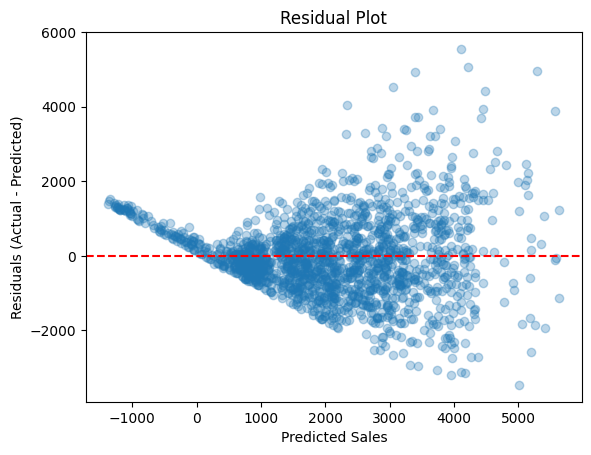

In [39]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

**Answer:** the residuals fan out — tight for low predicted sales but spreading widely for high predicted sales (heteroscedasticity). The model is reliable for typical/low-volume products but loses accuracy for high-performing outlets, exactly where confidence matters most.

#### Q21 (Bonus) — Does log-transforming the target help?
`Item_Outlet_Sales` is right-skewed (skew ≈ 1.18). Test whether predicting `log(sales)` improves the fit.

In [40]:
y_log = np.log1p(y)  # log1p handles zeros safely

x_train_l, x_test_l, y_train_l, y_test_l = train_test_split(
    x, y_log, test_size=0.2, random_state=42
)

lr_log = LinearRegression().fit(x_train_l, y_train_l)

# Back-transform predictions to the original scale for a fair comparison
y_pred_l = np.expm1(lr_log.predict(x_test_l))
y_true_l = np.expm1(y_test_l)

print("R2  (log target):", r2_score(y_true_l, y_pred_l))
print("MAE (log target):", mean_absolute_error(y_true_l, y_pred_l))

R2  (log target): 0.5659310645156821
MAE (log target): 746.7129509727763


**Answer:** the log-transform **improves MAE** (~793 → ~747) while R² stays roughly flat. It helps typical predictions but doesn't recover the missing high-sales signal.

#### Q22 (Bonus) — Cross-validation
A single 80/20 split could be lucky. 5-fold CV checks whether R² is stable.

In [41]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LinearRegression(), x, y, cv=5, scoring="r2")
print("R2 per fold:", cv_scores)
print("Mean R2   :", cv_scores.mean())
print("Std       :", cv_scores.std())

R2 per fold: [0.57067698 0.55088952 0.54568976 0.56243794 0.56247838]
Mean R2   : 0.5584345159521271
Std       : 0.008962297073042448


**Answer:** R² is stable across folds (mean ≈ 0.56, std ≈ 0.01), so the single-split result is trustworthy, not a lucky draw.

## Part G — Summary & Findings

**Problem:** Predict `Item_Outlet_Sales` from product and outlet attributes using Multiple Linear Regression.

**Data cleaning:** Imputed `Item_Weight` from each product's own average (global mean as fallback, justified by near-zero skew) and `Outlet_Size` from the most common size within each `Outlet_Type` (missingness was concentrated in Grocery Store and Supermarket Type1). Standardised inconsistent `Item_Fat_Content` labels and treated zero-visibility entries as disguised missing values, replacing them with each product's average visibility.

**Key findings:**
- `Outlet_Type` is the strongest predictor — Supermarket Type3 outlets sell far more than Grocery Stores.
- `Item_MRP` is the second-strongest predictor once coefficients are scaled — raw coefficients understated its importance.
- `Item_Weight` and `Item_Visibility` add almost no predictive value.

**Model performance:** R² ≈ 0.58, MAE ≈ ₹793. 5-fold cross-validation confirmed this is stable (mean R² ≈ 0.56, std ≈ 0.01).

**Limitations:** Log-transforming the target improved MAE (~793 → ~747) but not R², so skew isn't the main accuracy limit. Residual analysis showed a funnel shape (heteroscedasticity) — errors widen for high-sales predictions. The moderate R² likely reflects real-world drivers not in this dataset (promotions, local competition, seasonality) rather than a modelling flaw.

**Next steps:** try tree-based models (Random Forest, Gradient Boosting) which typically beat linear regression on this dataset, and wrap preprocessing in a scikit-learn `Pipeline` to eliminate the data-leakage noted in Part B.